<a href="https://colab.research.google.com/github/AdisornChamnongchit/Pandas_Origin_Fiber_2026/blob/main/(Success)_Ontime_Jan_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split

In [17]:
# 1. Install Thai fonts
!apt-get update
!apt-get install -y fonts-thai-tlwg

# 2. Import necessary libraries
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# 3. Specify the font path and add it to font_manager
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf' # Using Laksaman font as an example
fm.fontManager.addfont(font_path)

# 4. Set Matplotlib's default font and handle unicode minus sign
rcParams['font.family'] = 'Laksaman' # Set the primary font family to Laksaman
rcParams['font.sans-serif'] = 'Laksaman' # Also set for sans-serif fonts
rcParams['axes.unicode_minus'] = False # Prevent minus signs from appearing as squares

Hit:1 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:2 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:3 https://cli.github.com/packages stable InRelease [3,917 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:5 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:6 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:7 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [356 B]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [85.0 kB]
Get:11 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease [24.6 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-updates/restricted amd64 Packages [6,607 kB]
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,712 kB]
Get:

In [8]:
df = pd.read_excel("/content/Summary KPI 2026.xlsx")
df.head(5)

,Team Name,Staff name,ประเภทของงาน,Siebel Request No.,Fibre ID,วันนัดหมาย,Slot (xx.xx-xx.xx) ตย. 13.00-16.00,หัวข้อ Defend,ระบุสาเหตุ *กรณีติดปัญหางานก่อนหน้า,Description(ระบุรายละเอียด),Status,Month,Sum of number
0,Origin Fiber (Zone 2),อิทธิฤทธิ์ เพ็งพูล (Aitteerit Phengpun),MA,S-25-267899036,8801492820,2569-01-01 00:00:00,09:00-12:00,ระบบมีปัญหา,NaN,งานเป็นงาน Slot 14:30 น. ไม่ใช่ 09:00 อ้างอิง ...,Pending Defend,มกราคม,1
1,Origin Fiber (Zone 2),อิทธิฤทธิ์ เพ็งพูล (Aitteerit Phengpun),MA,S-26-268091241,8803425952,2569-01-03 00:00:00,09:00-12:00,Not Defend,NaN,Not Defend รถติดไม่ใช่สาเหตุ Slot 09:00,Pending Defend,มกราคม,1
2,Origin Fiber (Zone 2),วชิรวิทย์ ปาลกะวงศ์ ณ อยุธยา(Wachirawit Pankaw...,MA,S-26-267861696,8802445466,2569-01-03 00:00:00,12:00-15:00,ติดต่อลูกค้าไม่ได้,NaN,เช็คอินล่าช้าเนื่องจากติดต่อลูกค้าไม่ได้,Pending Defend,มกราคม,1
3,Origin Fiber (Zone 2),นันทวัฒน์ มูลกระโทก (Nanthawat Moonkrathok),MA,S-26-268243930,8801867276,2569-01-04 00:00:00,12:00-15:00,ติดปัญหาหน้างานก่อนหน้า,NaN,ติดปัญหาหน้างานก่อนหน้า 11:00 8805732583 Slot ...,Pending Defend,มกราคม,1
4,Origin Fiber (Zone 2),อนันต์ มีชำนาญ (Anan Michamnan),MA,S-26-268213013,8804223415,2569-01-04 00:00:00,14:00-17:00,ติดปัญหา job ก่อนหน้า - ติดปัญหาเทคนิค,NaN,NaN,Pending Defend,มกราคม,1


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 13 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Team Name                            62 non-null     object 
 1   Staff name                           62 non-null     object 
 2   ประเภทของงาน                         62 non-null     object 
 3   Siebel Request No.                   56 non-null     object 
 4   Fibre ID                             62 non-null     object 
 5   วันนัดหมาย                           62 non-null     object 
 6   Slot (xx.xx-xx.xx) ตย. 13.00-16.00   62 non-null     object 
 7   หัวข้อ Defend                        62 non-null     object 
 8   ระบุสาเหตุ *กรณีติดปัญหางานก่อนหน้า  0 non-null      float64
 9   Description(ระบุรายละเอียด)          61 non-null     object 
 10  Status                               62 non-null     object 
 11  Month                             

In [10]:
df.describe()

,ระบุสาเหตุ *กรณีติดปัญหางานก่อนหน้า,Sum of number
count,0.0,62.0
mean,NaN,1.0
std,NaN,0.0
min,NaN,1.0
25%,NaN,1.0
50%,NaN,1.0
75%,NaN,1.0
max,NaN,1.0


In [12]:
df.shape

(62, 13)

In [13]:
df.columns

Index(['Team Name', 'Staff name', 'ประเภทของงาน', 'Siebel Request No.',
       'Fibre ID', 'วันนัดหมาย', 'Slot (xx.xx-xx.xx) ตย. 13.00-16.00',
       'หัวข้อ Defend', 'ระบุสาเหตุ *กรณีติดปัญหางานก่อนหน้า',
       'Description(ระบุรายละเอียด)', 'Status', 'Month', 'Sum of number'],
      dtype='object')

In [14]:
df.dtypes

,0
Team Name,object
Staff name,object
ประเภทของงาน,object
Siebel Request No.,object
Fibre ID,object
วันนัดหมาย,object
Slot (xx.xx-xx.xx) ตย. 13.00-16.00,object
หัวข้อ Defend,object
ระบุสาเหตุ *กรณีติดปัญหางานก่อนหน้า,float64
Description(ระบุรายละเอียด),object


In [15]:
df['Staff name'].value_counts()

,count
Staff name,
อิทธิฤทธิ์ เพ็งพูล (Aitteerit Phengpun),11
วชิรวิทย์ ปาลกะวงศ์ ณ อยุธยา(Wachirawit Pankawong-na-ayuttaya),5
อนันต์ มีชำนาญ (Anan Michamnan),5
ตะวัน เสวกพันธุ์ (Tawan Sawekphan),5
ชวิน รวมธรรม (Chawin Ruamtham),4
อัครเดช ทองนิล (Arkkharadet Thongnin),4
นพดล ทองอยู่ (Noppadoi Thongyu),3
นัทธมน เสวกพันธุ์ (Nattamon Saewokphan),3
นันทวัฒน์ มูลกระโทก (Nanthawat Moonkrathok),3


/tmp/ipython-input-986059457.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Staff name', data=staff_counts_df, palette='viridis')


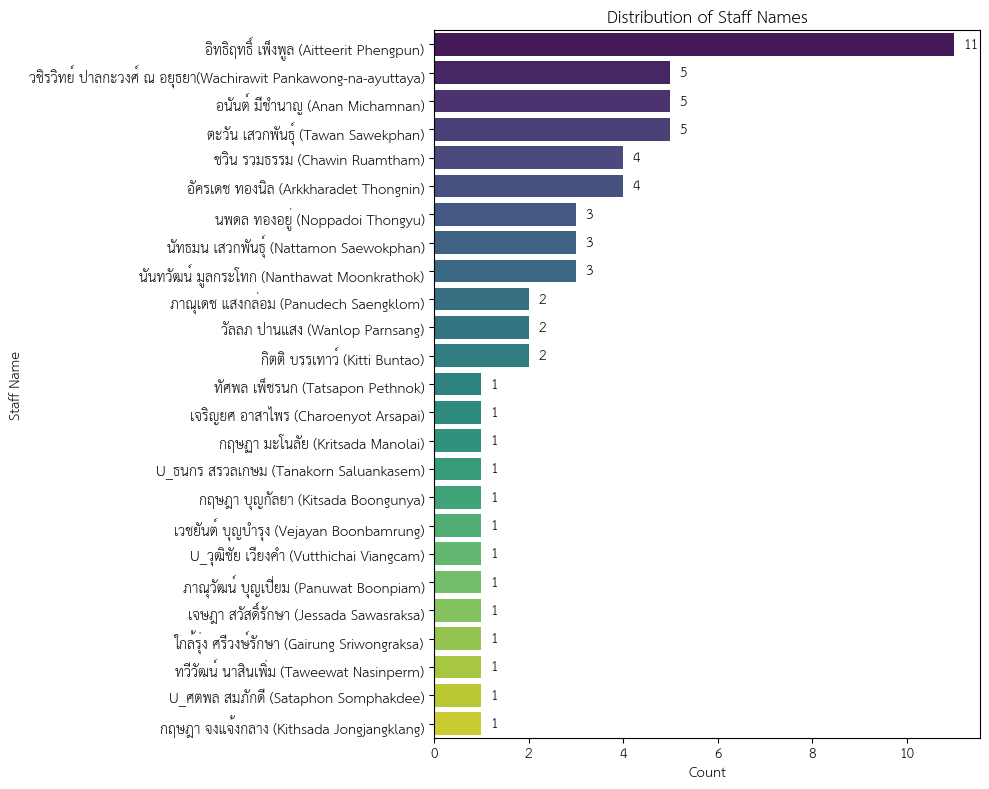

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib import rcParams

# Configure font to support Thai characters (already done in C4zp29l8FtD4, reiterating for clarity/to ensure it's applied to this cell)
# It's good practice to ensure font settings are applied if this cell is run independently.
# Based on cell C4zp29l8FtD4, the font 'Laksaman' has been added and set.
# Ensure these settings are applied here if they weren't globally or if running this cell alone.
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Calculate value counts for 'Staff name'
staff_counts = df['Staff name'].value_counts()

# Create a DataFrame from the series for easier plotting with seaborn
staff_counts_df = staff_counts.reset_index()
staff_counts_df.columns = ['Staff name', 'Count']

# Create the horizontal bar plot
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability
ax = sns.barplot(x='Count', y='Staff name', data=staff_counts_df, palette='viridis')

# Add numerical labels to the bars
for index, row in staff_counts_df.iterrows():
    ax.text(row['Count'] + 0.2, index, str(row['Count']), color='black', ha="left", va="center")

plt.title('Distribution of Staff Names')
plt.xlabel('Count')
plt.ylabel('Staff Name')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [22]:
defend_score = df['หัวข้อ Defend'].value_counts()
defend_score

,count
หัวข้อ Defend,
Not Defend,22
ติดปัญหาหน้างานก่อนหน้า,15
Over Slot,6
ลูกค้าสะดวกคร่อม Slot,5
Install Not Defend,4
ติดต่อลูกค้าไม่ได้,4
ระบบมีปัญหา,3
ติดปัญหา job ก่อนหน้า - ติดปัญหาเทคนิค,1
รถเสีย,1


/tmp/ipython-input-1637025868.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Defend Topic', data=defend_counts_df, palette='magma')


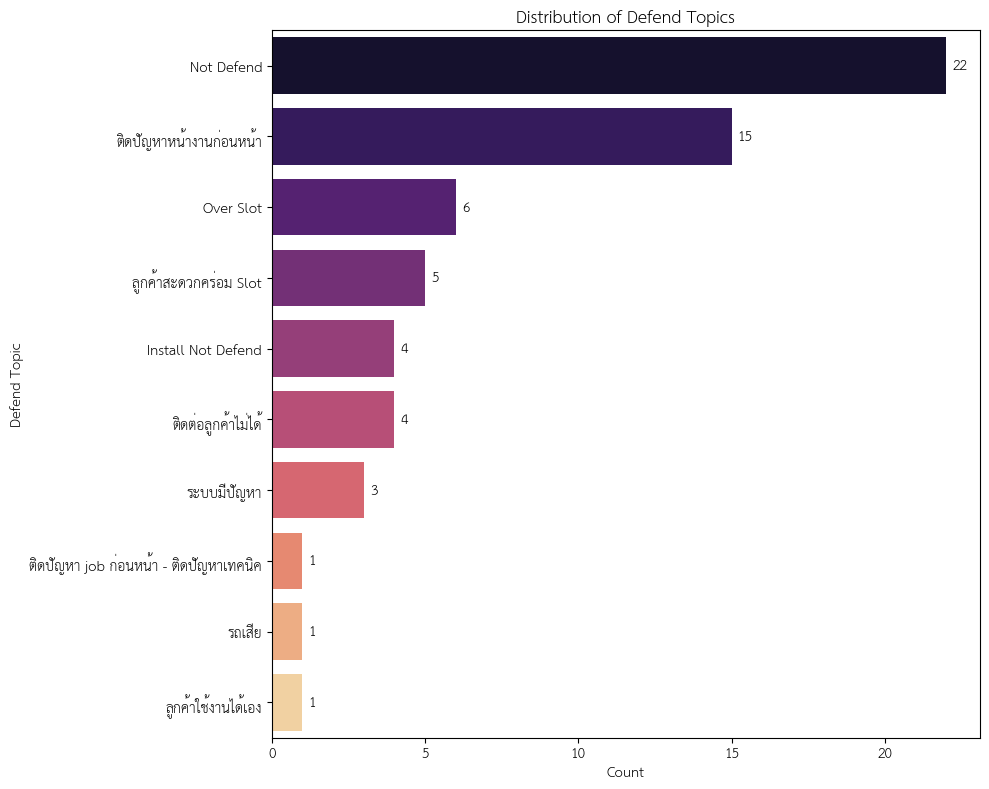

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib import rcParams

# Configure font to support Thai characters (reiterate for new plot)
# This assumes the font 'Laksaman' has been added and set globally as in C4zp29l8FtD4
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Calculate value counts for 'หัวข้อ Defend' (already done, use defend_score)
defend_counts_df = defend_score.reset_index()
defend_counts_df.columns = ['Defend Topic', 'Count']

# Create the horizontal bar plot
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability
ax = sns.barplot(x='Count', y='Defend Topic', data=defend_counts_df, palette='magma')

# Add numerical labels to the bars
for index, row in defend_counts_df.iterrows():
    ax.text(row['Count'] + 0.2, index, str(row['Count']), color='black', ha="left", va="center")

plt.title('Distribution of Defend Topics')
plt.xlabel('Count')
plt.ylabel('Defend Topic')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [27]:
df['ประเภทของงาน'].value_counts()

,count
ประเภทของงาน,
MA,56
Install,6


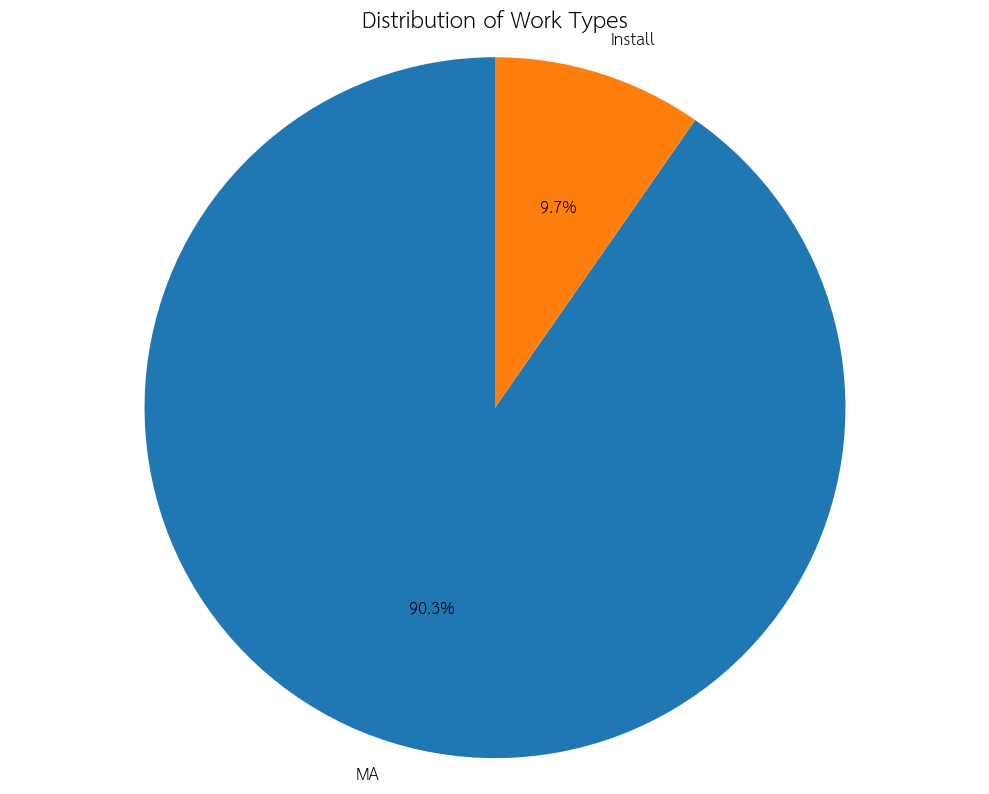

In [30]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib import rcParams

# Configure font to support Thai characters (reiterate for new plot)
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Get value counts for 'ประเภทของงาน'
work_type_counts = df['ประเภทของงาน'].value_counts()

# Create the pie chart
plt.figure(figsize=(10, 8)) # Adjust figure size
plt.pie(work_type_counts, labels=work_type_counts.index, autopct='%1.1f%%', startangle=90, textprops={'fontsize': 12})
plt.title('Distribution of Work Types', fontsize=16)
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

In [31]:
df['วันนัดหมาย'].value_counts()

,count
วันนัดหมาย,
2569-01-22 00:00:00,5
2569-01-10 00:00:00,4
2569-01-17 00:00:00,4
2569-01-19 00:00:00,4
2569-01-16 00:00:00,4
2569-01-24 00:00:00,4
2569-01-23 00:00:00,3
2569-01-15 00:00:00,3
2569-01-13 00:00:00,3


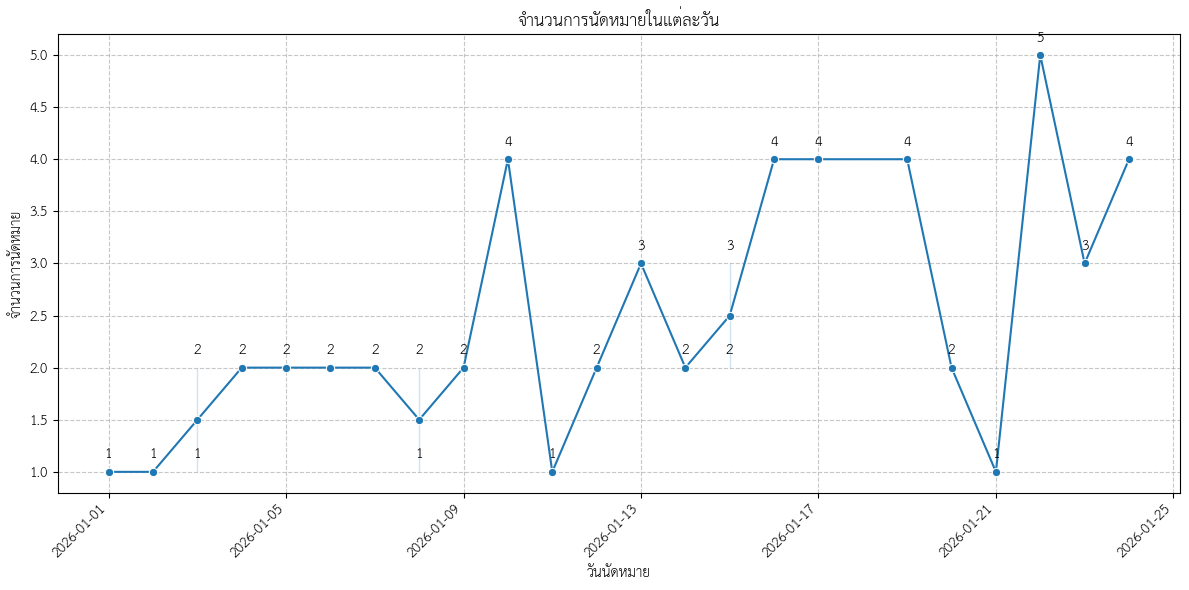

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd
from matplotlib import rcParams

# Configure font to support Thai characters
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Get value counts for 'วันนัดหมาย'
daily_appointment_counts = df['วันนัดหมาย'].value_counts().reset_index()
daily_appointment_counts.columns = ['วันนัดหมาย', 'จำนวน']

# Convert 'วันนัดหมาย' to string first to handle mixed types safely
daily_appointment_counts['วันนัดหมาย'] = daily_appointment_counts['วันนัดหมาย'].astype(str)

# Function to convert Buddhist year to Gregorian year
def convert_buddhist_year_to_gregorian(date_str):
    year_str = date_str.split('-')[0]
    if int(year_str) > 2500: # Assuming years greater than 2500 are Buddhist years
        gregorian_year = int(year_str) - 543
        return str(gregorian_year) + '-' + '-'.join(date_str.split('-')[1:])
    return date_str

# Apply the conversion to the 'วันนัดหมาย' column
daily_appointment_counts['วันนัดหมาย'] = daily_appointment_counts['วันนัดหมาย'].apply(convert_buddhist_year_to_gregorian)

# Convert 'วันนัดหมาย' to datetime objects and sort for correct line plot order
daily_appointment_counts['วันนัดหมาย'] = pd.to_datetime(daily_appointment_counts['วันนัดหมาย'])
daily_appointment_counts = daily_appointment_counts.sort_values(by='วันนัดหมาย')

# Create the line plot
plt.figure(figsize=(12, 6)) # Adjust figure size for better readability
ax = sns.lineplot(x='วันนัดหมาย', y='จำนวน', data=daily_appointment_counts, marker='o')

# Add numerical labels to the data points
for index, row in daily_appointment_counts.iterrows():
    ax.text(row['วันนัดหมาย'], row['จำนวน'] + 0.1, str(row['จำนวน']), color='black', ha="center", va="bottom")

plt.title('จำนวนการนัดหมายในแต่ละวัน')
plt.xlabel('วันนัดหมาย')
plt.ylabel('จำนวนการนัดหมาย')
plt.xticks(rotation=45, ha='right') # Rotate date labels for better readability
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [35]:
staff_defend_counts = df.groupby(['Staff name', 'หัวข้อ Defend']).size()
staff_defend_pivot = staff_defend_counts.unstack(fill_value=0)
staff_defend_pivot.head()

หัวข้อ Defend,Install Not Defend,Not Defend,Over Slot,ติดต่อลูกค้าไม่ได้,ติดปัญหา job ก่อนหน้า - ติดปัญหาเทคนิค,ติดปัญหาหน้างานก่อนหน้า,รถเสีย,ระบบมีปัญหา,ลูกค้าสะดวกคร่อม Slot,ลูกค้าใช้งานได้เอง
Staff name,,,,,,,,,,
U_ธนกร สรวลเกษม (Tanakorn Saluankasem),1,0,0,0,0,0,0,0,0,0
U_วุฒิชัย เวียงคำ (Vutthichai Viangcam),1,0,0,0,0,0,0,0,0,0
U_ศตพล สมภักดี (Sataphon Somphakdee),0,1,0,0,0,0,0,0,0,0
กฤษฎา จงแจ้งกลาง (Kithsada Jongjangklang),0,1,0,0,0,0,0,0,0,0
กฤษฎา บุญกัลยา (Kitsada Boongunya),0,1,0,0,0,0,0,0,0,0


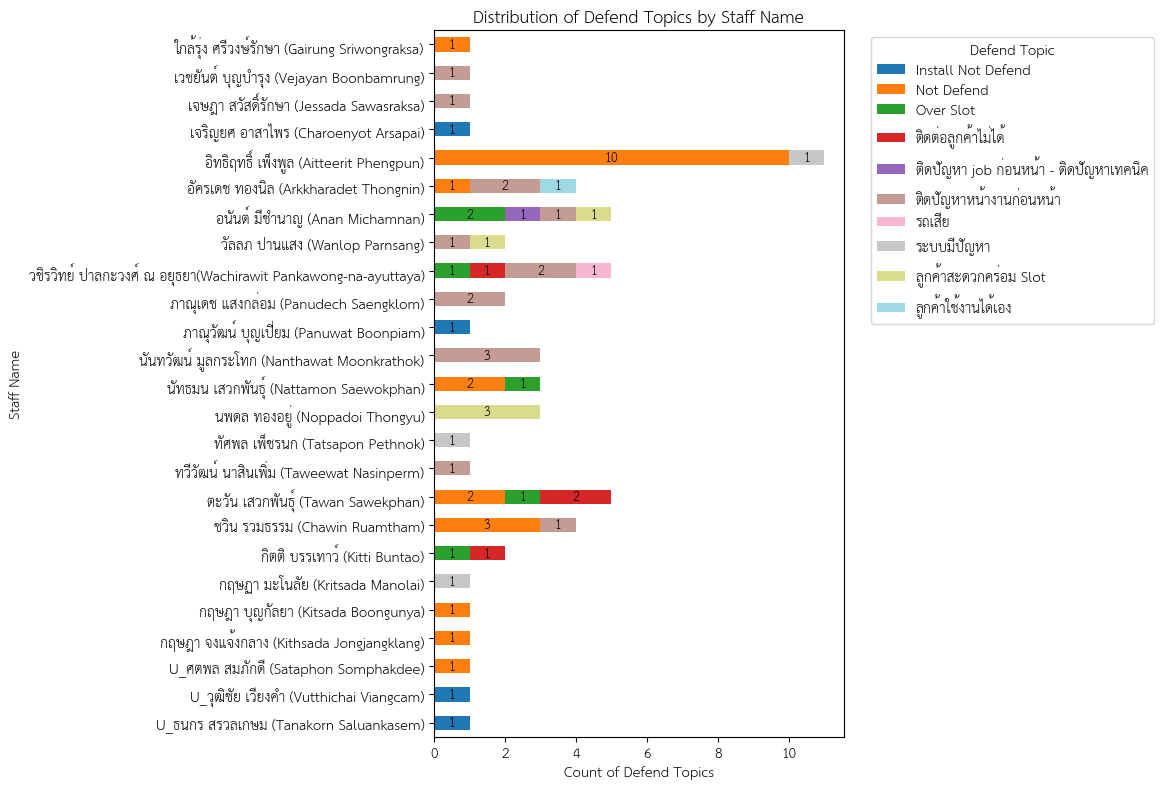

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib import rcParams

# Configure font to support Thai characters (reiterate for new plot)
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Plotting the horizontal stacked bar chart
ax = staff_defend_pivot.plot(kind='barh', stacked=True, figsize=(12, 8), cmap='tab20')

# Add numerical labels to the bars
for container in ax.containers:
    # Iterate over each bar in the container
    for bar in container:
        width = bar.get_width()
        height = bar.get_height()
        x = bar.get_x()
        y = bar.get_y()

        # Only label non-zero segments
        if width > 0:
            ax.text(x + width / 2, y + height / 2, # x, y position
                    f'{int(width)}',             # label text (width is now the count for barh)
                    ha='center', va='center',     # alignment
                    color='black', fontsize=9)

plt.title('Distribution of Defend Topics by Staff Name')
plt.xlabel('Count of Defend Topics') # Swapped with ylabel for horizontal chart
plt.ylabel('Staff Name')             # Swapped with xlabel for horizontal chart
plt.xticks(rotation=0) # No rotation needed for x-axis labels
plt.legend(title='Defend Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [38]:
# Filter the DataFrame for 'Not Defend' topics and 'MA' work type
not_defend_ma_staff = df[(df['หัวข้อ Defend'] == 'Not Defend') & (df['ประเภทของงาน'] == 'MA')]

# Display the unique staff names from the filtered data
print("พนักงานที่มีหัวข้อ Defend เป็น 'Not Defend' และประเภทงาน 'MA':\n")
print(not_defend_ma_staff['Staff name'].unique())

พนักงานที่มีหัวข้อ Defend เป็น 'Not Defend' และประเภทงาน 'MA':

['อิทธิฤทธิ์ เพ็งพูล (Aitteerit Phengpun)'
 'ชวิน รวมธรรม (Chawin Ruamtham)' 'ตะวัน เสวกพันธุ์ (Tawan Sawekphan)'
 'กฤษฎา บุญกัลยา (Kitsada Boongunya)'
 'ใกล้รุ่ง ศรีวงษ์รักษา (Gairung Sriwongraksa)'
 'อัครเดช ทองนิล (Arkkharadet Thongnin)'
 'นัทธมน เสวกพันธุ์ (Nattamon Saewokphan)']


/tmp/ipython-input-863169102.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Staff name', data=not_defend_ma_counts_df, palette='viridis')


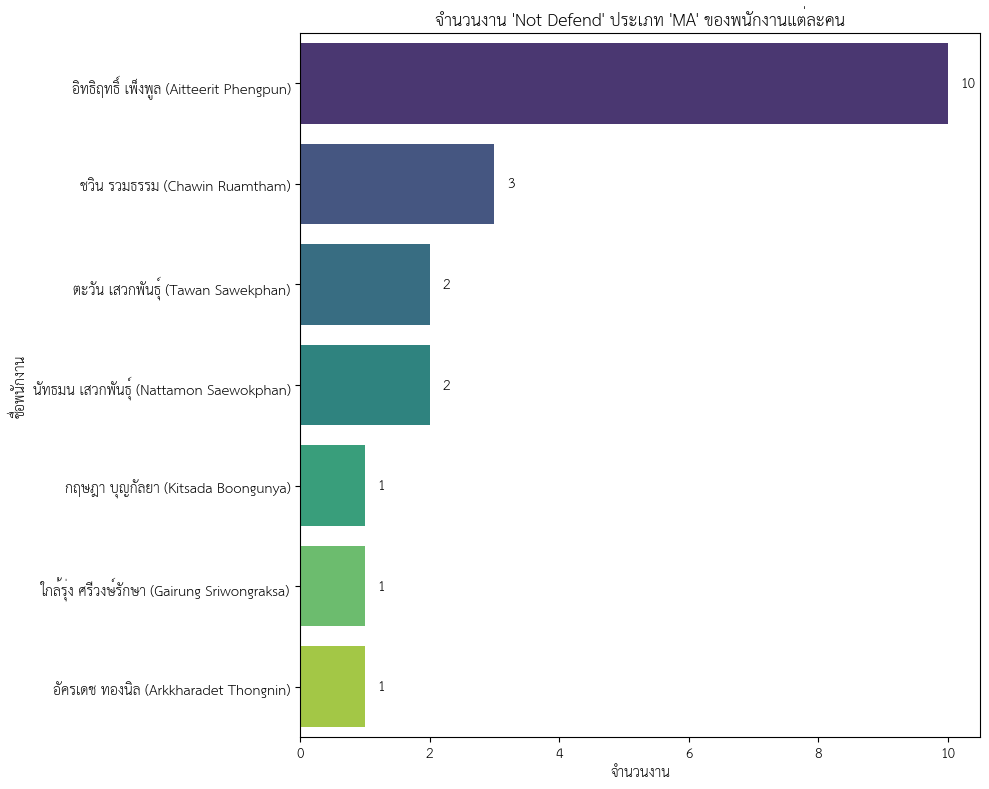

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
from matplotlib import rcParams

# Configure font to support Thai characters
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Calculate value counts for 'Staff name' in the filtered data
not_defend_ma_counts = not_defend_ma_staff['Staff name'].value_counts()

# Create a DataFrame from the series for easier plotting with seaborn
not_defend_ma_counts_df = not_defend_ma_counts.reset_index()
not_defend_ma_counts_df.columns = ['Staff name', 'Count']

# Create the horizontal bar plot
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability
ax = sns.barplot(x='Count', y='Staff name', data=not_defend_ma_counts_df, palette='viridis')

# Add numerical labels to the bars
for index, row in not_defend_ma_counts_df.iterrows():
    ax.text(row['Count'] + 0.2, index, str(row['Count']), color='black', ha="left", va="center")

plt.title('จำนวนงาน \'Not Defend\' ประเภท \'MA\' ของพนักงานแต่ละคน')
plt.xlabel('จำนวนงาน')
plt.ylabel('ชื่อพนักงาน')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

In [42]:
df.columns

Index(['Team Name', 'Staff name', 'ประเภทของงาน', 'Siebel Request No.',
       'Fibre ID', 'วันนัดหมาย', 'Slot (xx.xx-xx.xx) ตย. 13.00-16.00',
       'หัวข้อ Defend', 'ระบุสาเหตุ *กรณีติดปัญหางานก่อนหน้า',
       'Description(ระบุรายละเอียด)', 'Status', 'Month', 'Sum of number'],
      dtype='object')

In [44]:
df['Slot (xx.xx-xx.xx) ตย. 13.00-16.00'].value_counts()

,count
Slot (xx.xx-xx.xx) ตย. 13.00-16.00,
09:00-12:00,14
12:00-15:00,9
09:00-11:30,5
18:00-21:00,5
15:00-18:00,5
10:00-13:00,4
09:30-12:30,3
18:00-20:30,2
13:00-16:00,2


/tmp/ipython-input-4140913300.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Count', y='Time Slot', data=slot_counts, palette='crest')


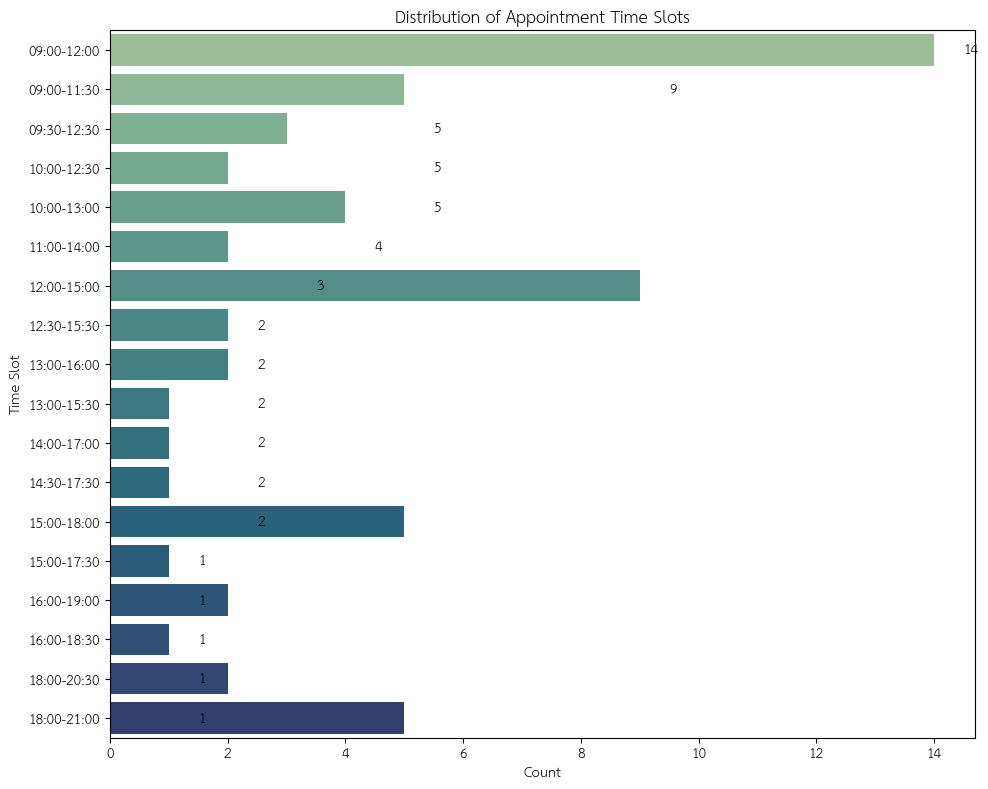

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm
import pandas as pd
from matplotlib import rcParams

# Configure font to support Thai characters
font_path = '/usr/share/fonts/truetype/tlwg/Laksaman.ttf'
if fm.findfont('Laksaman') is None:
    fm.fontManager.addfont(font_path)

rcParams['font.family'] = 'Laksaman'
rcParams['font.sans-serif'] = 'Laksaman'
rcParams['axes.unicode_minus'] = False

# Get value counts for 'Slot (xx.xx-xx.xx) ตย. 13.00-16.00'
slot_counts = df['Slot (xx.xx-xx.xx) ตย. 13.00-16.00'].value_counts().reset_index()
slot_counts.columns = ['Time Slot', 'Count']

# Function to extract sortable key from time slot string (e.g., '09:00-12:00' -> '09:00')
def get_sort_key(time_slot_str):
    # Extract the start time part (e.g., '09:00' from '09:00-12:00')
    return time_slot_str.split('-')[0]

# Add a temporary column for sorting
slot_counts['Sort Key'] = slot_counts['Time Slot'].apply(get_sort_key)

# Sort the DataFrame by the 'Sort Key'
slot_counts = slot_counts.sort_values(by='Sort Key')

# Create the horizontal bar plot
plt.figure(figsize=(10, 8)) # Adjust figure size for better readability
ax = sns.barplot(x='Count', y='Time Slot', data=slot_counts, palette='crest')

# Add numerical labels to the bars with improved positioning and font size
for index, row in slot_counts.iterrows():
    ax.text(row['Count'] + 0.5, index, str(row['Count']), color='black', ha="left", va="center", fontsize=10)

plt.title('Distribution of Appointment Time Slots')
plt.xlabel('Count')
plt.ylabel('Time Slot')
plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()